In [1]:
import os
import re
import json
import pandas as pd
import numpy as np
from tqdm import tqdm
from datetime import datetime

import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib.colors import BoundaryNorm
from matplotlib.colors import ListedColormap


from patsy import dmatrices
import bambi as bmb
import arviz as az
from scipy.stats import chi2
import statsmodels.api as sm
import matplotlib.pyplot as plt
from IPython.display import display
import statsmodels.formula.api as smf
from scipy.stats import chi2_contingency
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.outliers_influence import variance_inflation_factor

from util import *

sns.set_palette('colorblind')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

In [2]:
msnbc_urls = [
    "https://www.instagram.com/msnbc/reel/DQz6GiKkqD-/",
    "https://www.instagram.com/msnbc/reel/DQzvigyiu3R/",
    "https://www.instagram.com/msnbc/reel/DQzaxBeisq2/",
    "https://www.instagram.com/msnbc/reel/DQzOhJyil7B/",
    "https://www.instagram.com/msnbc/reel/DQx_MsXDdqz/",
    "https://www.instagram.com/reel/DQx6d6TDFvD/",
    "https://www.instagram.com/reel/DQxz17nkXAu/",
    "https://www.instagram.com/reel/DQxxwsjEQxy/",
    "https://www.instagram.com/reel/DQxf5uvERD0/",
    "https://www.instagram.com/reel/DQxc21kkqwR/",
]

huffpost_urls = [
    "https://www.instagram.com/huffpost/reel/DQzSuMQARR0/",
    "https://www.instagram.com/huffpost/p/DQxLW-PEns-/",
    "https://www.instagram.com/huffpost/reel/DQxARFuAbt-/",
    "https://www.instagram.com/huffpost/reel/DQw6Qa_kWgY/",
    "https://www.instagram.com/huffpost/reel/DQw5_xHkWod/",
    "https://www.instagram.com/huffpost/reel/DQwbCxQjQNQ/",
    "https://www.instagram.com/huffpost/p/DQu2w59E9t-/",
    "https://www.instagram.com/huffpost/reel/DQvEm2FDCmz/",
    "https://www.instagram.com/huffpost/p/DQuw7U7D322/",
    "https://www.instagram.com/p/DQujjUrk61E/"
]

cnn_urls = [
    "https://www.instagram.com/reel/DQ0VgDjjx7K/",
    "https://www.instagram.com/p/DQ0LWj6jue3/",
    "https://www.instagram.com/reel/DQz7vqJiEUj/",
    "https://www.instagram.com/reel/DQznNr7gp1F/",
    "https://www.instagram.com/reel/DQzgXgPgPmN/",
    "https://www.instagram.com/reel/DQzNYM8ARN3/",
    "https://www.instagram.com/reel/DQzEp0pChCY/",
    "https://www.instagram.com/reel/DQy-AdiCcH_/",
    "https://www.instagram.com/reel/DQyzpQVjga4/",
    "https://www.instagram.com/reel/DQypWvmDoge/"
]

washingtonpost_urls = [
    "https://www.instagram.com/washingtonpost/p/DQ0JgL9DqcC/",
    "https://www.instagram.com/washingtonpost/p/DQz7wRODMr8/",
    "https://www.instagram.com/washingtonpost/p/DQzuD3fFJcu/",
    "https://www.instagram.com/washingtonpost/reel/DQzh-t0DSAJ/",
    "https://www.instagram.com/washingtonpost/reel/DQzgTDHAcKl/",
    "https://www.instagram.com/p/DQzZihPDiQv/",
    "https://www.instagram.com/reel/DQzSo12D1fJ/",
    "https://www.instagram.com/reel/DQzLtq3ARq3/",
    "https://www.instagram.com/p/DQxxk6BDvZh/",
    "https://www.instagram.com/p/DQxqaCpDcHC/"
]

forbes_urls = [
    "https://www.instagram.com/forbes/p/DQ0Ck-lgUxt/",
    "https://www.instagram.com/forbes/p/DQz0444AWAd/",
    "https://www.instagram.com/forbes/p/DQzgP9_gcjC/",
    "https://www.instagram.com/p/DQzUOiGAblX/",
    "https://www.instagram.com/p/DQzLpqJDxMD/",
    "https://www.instagram.com/p/DQzFWzxkT-c/",
    "https://www.instagram.com/p/DQxdypCDPF2/",
    "https://www.instagram.com/p/DQxOpmbkn_b/",
    "https://www.instagram.com/p/DQxFjBJj4gS/",
    "https://www.instagram.com/p/DQxElAzD6aK/"
]

thehill_urls = [
    "https://www.instagram.com/thehill/p/DQzfVDcE3YB/",
    "https://www.instagram.com/thehill/p/DQxg1ufkeqR/",
    "https://www.instagram.com/thehill/reel/DQxViLFEdQ5/",
    "https://www.instagram.com/thehill/p/DQw1LZxEwrn/",
    "https://www.instagram.com/thehill/p/DQwgkZxD2Ug/",
    "https://www.instagram.com/thehill/reel/DQvAK9hEeWU/",
    "https://www.instagram.com/thehill/p/DQunQLokn-7/",
    "https://www.instagram.com/thehill/reel/DQuNa5zEeiR/",
    "https://www.instagram.com/thehill/p/DQt9lxsjumG/",
    "https://www.instagram.com/reel/DQrpC35EXqn/"
]

washingtontimes_urls = [
    "https://www.instagram.com/washtimes/p/DQz0CxJExjr/",
    "https://www.instagram.com/washtimes/p/DQzcWsGkg8C/",
    "https://www.instagram.com/washtimes/p/DQxHICQE_29/",
    "https://www.instagram.com/washtimes/p/DQw_V8sE6ZH/",
    "https://www.instagram.com/washtimes/p/DQw3jz6k0L6/",
    "https://www.instagram.com/washtimes/p/DQwvq-dktiv/",
    "https://www.instagram.com/washtimes/p/DQwn4b2EzCR/",
    "https://www.instagram.com/washtimes/p/DQwgGZ2jQck/",
    "https://www.instagram.com/washtimes/p/DQvCB1iEwBa/",
    "https://www.instagram.com/washtimes/reel/DQu5zA1CL3U/"
]

nypost_urls = [
    "https://www.instagram.com/p/DQ0Jd_SAc4Z/",
    "https://www.instagram.com/p/DQ0GBAngWyx/",
    "https://www.instagram.com/reel/DQ0ETkoDtLN/",
    "https://www.instagram.com/p/DQ0ClEugU1r/",
    "https://www.instagram.com/p/DQz_JRkAWr9/",
    "https://www.instagram.com/reel/DQz9kQIDZOc/",
    "https://www.instagram.com/p/DQz70tPAQTn/",
    "https://www.instagram.com/p/DQz4Y1Xgadc/",
    "https://www.instagram.com/reel/DQz2rWGEkpe/",
    "https://www.instagram.com/p/DQz09vagSe1/"
]

foxnews_urls = [
    "https://www.instagram.com/reel/DQ0V_qAEfwE/",
    "https://www.instagram.com/reel/DQ0UdiODE-2/",
    "https://www.instagram.com/reel/DQ0UNIZD3rv/",
    "https://www.instagram.com/reel/DQ0OfgWAswZ/",
    "https://www.instagram.com/reel/DQ0OAwCk91U/",
    "https://www.instagram.com/reel/DQ0GaXEjofE/",
    "https://www.instagram.com/reel/DQ0ClztkmYz/",
    "https://www.instagram.com/p/DQ0AYUTkvh4/",
    "https://www.instagram.com/p/DQz8ZTUjJ4s/",
    "https://www.instagram.com/reel/DQz8UW2j4TQ/"
]

breitbart_urls = [
    "https://www.instagram.com/p/DQ0P_UtDFLj/",
    "https://www.instagram.com/p/DQ0ImR1DaM0/",
    "https://www.instagram.com/p/DQz28XJkuQV/",
    "https://www.instagram.com/p/DQzkN12CUZQ/",
    "https://www.instagram.com/reel/DQzXuPOkgOo/",
    "https://www.instagram.com/p/DQzR5CjkQxS/",
    "https://www.instagram.com/p/DQzJCenDSPC/",
    "https://www.instagram.com/p/DQy1VfcETEi/",
    "https://www.instagram.com/reel/DQxZ3LCkvgh/",
    "https://www.instagram.com/p/DQxfi8JjVGb/"
]

all_urls = {
    'msnbc': msnbc_urls,
    'huffpost': huffpost_urls,
    'cnn': cnn_urls,
    'washingtonpost': washingtonpost_urls,
    'forbes': forbes_urls,
    'thehill': thehill_urls,
    'washingtontimes': washingtontimes_urls,
    'nypost': nypost_urls,
    'foxnews': foxnews_urls,
    'breitbart': breitbart_urls
}

In [3]:
# all_crawls = ['ny_1', 'texas_1',
#               'male_dem_ny_1', 'male_dem_texas_1',
#               'male_rep_ny_1', 'male_rep_texas_1',
#               'female_dem_ny_1', 'female_dem_texas_1',
#               'female_rep_ny_1', 'female_rep_texas_1']

all_crawls = ['ny_1',
              'male_dem_ny_1',
              'male_rep_ny_1',
              'female_dem_ny_1',
              'female_rep_ny_1']

file_path = '/Users/brahmaninutakki/saarland/insta-comments/saved_data/new'

### Merging and preprocessing

In [4]:
dfs = {}
for crawl in all_crawls:
    temp_list = []
    for account in all_urls.keys():

        accountfiles = os.listdir(f'{file_path}/{crawl}/{account}')
        file_ids = list({re.split(r'_(comments|timestamps)', fp)[0] for fp in accountfiles})

        for id_ in file_ids:

            # if both comments and timestamps files are present
            if f'{id_}_comments.json' in accountfiles and f'{id_}_timestamps.json' in accountfiles:

                with open(f'{file_path}/{crawl}/{account}/{id_}_comments.json', 'r') as f:
                    comments = json.load(f)
                with open(f'{file_path}/{crawl}/{account}/{id_}_timestamps.json', 'r') as f:
                    timestamps = json.load(f)
                
                caption, comments, likes = clean_comments(comments)

                # this particular comment is just ' '. so adding it manually.
                if id_ == 'DRVQXcWAaaw':
                    idx = comments.index('authoryuccaharris')
                    comments = comments[:idx+1] + [' '] + comments[idx+1:]
                # if id_ == 'DRYdTZHjT-E':
                #     idx = comments.index('danieleichenlaub')
                #     comments = comments[:idx+1] + [' '] + comments[idx+1:]


                # mapping usernames and comments to timestamps
                comments_map = {}

                # checking if comments (username + comment) and timestamps are of same length 
                if len(comments) == 2*len(timestamps):

                    if len(comments) % 2 == 0:

                        usernames = comments[::2]
                        comments_text = comments[1::2]

                        
                        for u, c, t in zip(usernames, comments_text, timestamps):
                            comments_map[(u, c)] = t

                        idx = 0
                        for c, v in comments_map.items():
                            temp_dict = {'account': account,
                                         'urlid': id_,
                                         'caption': caption,
                                         'comment_num': idx,
                                         f'{crawl}_comment': c,
                                         f'{crawl}_timestamp': v,
                                         'likes': likes} # TODO: check if likes here is correct
                            idx += 1
                            temp_list.append(temp_dict)

                else:
                    # if this happens, its mostly happening since a comment is empty string ''
                    print(f'comemnts-timestamps length mismatch', account, id_, crawl)
            else:
                # only comments file is present
                with open(f'{file_path}/{crawl}/{account}/{id_}_comments.json', 'r') as f:
                    comments = json.load(f)

                caption, comments, likes = clean_comments(comments)

                if len(comments) != 0:
                    print('no timestamp file and len(comments) != 0', id_, account, crawl, len(comments))
                    # if this happens its usually to do more cleaning of comements

    df = pd.DataFrame(temp_list)
    dfs[crawl] = df

In [5]:
for crawl, df in dfs.items():
    print(f'{crawl}: {df.shape}')

ny_1: (1188, 7)
male_dem_ny_1: (1062, 7)
male_rep_ny_1: (1155, 7)
female_dem_ny_1: (1087, 7)
female_rep_ny_1: (1089, 7)


In [6]:
for crawl, df in dfs.items():
    df.drop(columns=['caption', 'likes'], inplace=True, axis=1)

In [7]:
merged_df = dfs['ny_1'].copy()

for crawl, df in dfs.items():
    if crawl == 'ny_1':
        continue
    print(crawl)
    merged_df = pd.merge(merged_df, df, how='outer', on=['account', 'urlid', 'comment_num'])

male_dem_ny_1
male_rep_ny_1
female_dem_ny_1
female_rep_ny_1


In [8]:
# remove urls that have less than 10 comments

urlids = merged_df['urlid'].unique().tolist()
donotremove_urls = set()
for urlid in urlids:
    temp = merged_df[merged_df['urlid'] == urlid]
    num_rows = temp['comment_num'].max()
    if num_rows <= 8:
        continue
    else:
        donotremove_urls.add(urlid)

merged_df = merged_df[merged_df['urlid'].isin(donotremove_urls)]

In [9]:
# limiting to top 10 comments
merged_df = merged_df[merged_df['comment_num'] <= 9]
merged_df.shape

(860, 13)

In [10]:
temp_df = get_chronological_order_comments(merged_df, all_urls, all_crawls)
merged_df = pd.merge(merged_df, temp_df, how='outer', on=['account', 'urlid', 'comment_num'])

In [11]:
merged_df.drop(columns=[x for x in merged_df.columns if 'timestamp' in x], inplace=True)
merged_df.head()

,account,urlid,comment_num,ny_1_comment,male_dem_ny_1_comment,male_rep_ny_1_comment,female_dem_ny_1_comment,female_rep_ny_1_comment,chronological_comment
0,breitbart,DRWBiQXDG0H,0,"(torinejudith, ❤️)","(torinejudith, ❤️)","(torinejudith, ❤️)","(torinejudith, ❤️)","(torinejudith, ❤️)","(ryan.smith202, It’s not fissures in MAGA, it ..."
1,breitbart,DRWBiQXDG0H,1,"(terp00, Maga died when trump went Israel firs...","(terp00, Maga died when trump went Israel firs...","(scottishlyme, The actual LEFT should be calle...","(terp00, Maga died when trump went Israel firs...","(scottishlyme, The actual LEFT should be calle...","(terp00, Maga died when trump went Israel firs..."
2,breitbart,DRWBiQXDG0H,2,"(scottishlyme, The actual LEFT should be calle...","(scottishlyme, The actual LEFT should be calle...","(terp00, Maga died when trump went Israel firs...","(scottishlyme, The actual LEFT should be calle...","(terp00, Maga died when trump went Israel firs...","(_taco_______, 🤡🤡)"
3,breitbart,DRWBiQXDG0H,3,"(i_tr00per, WE ARE NOT COMING TOGETHER UNTIL T...","(i_tr00per, WE ARE NOT COMING TOGETHER UNTIL T...","(i_tr00per, WE ARE NOT COMING TOGETHER UNTIL T...","(i_tr00per, WE ARE NOT COMING TOGETHER UNTIL T...","(i_tr00per, WE ARE NOT COMING TOGETHER UNTIL T...","(loretta.bauer.35, I thought that was exactly ..."
4,breitbart,DRWBiQXDG0H,4,"(alton_klompus, @wearebreitbart slowly distanc...","(loretta.bauer.35, I thought that was exactly ...","(loretta.bauer.35, I thought that was exactly ...","(i_tr00per, Bernie Moreno has the most remedia...","(i_tr00per, Bernie Moreno has the most remedia...","(torinejudith, ❤️)"


In [12]:
merged_df.shape

(1102, 9)

### Plotting differences

In [13]:
merged_df.head()

,account,urlid,comment_num,ny_1_comment,male_dem_ny_1_comment,male_rep_ny_1_comment,female_dem_ny_1_comment,female_rep_ny_1_comment,chronological_comment
0,breitbart,DRWBiQXDG0H,0,"(torinejudith, ❤️)","(torinejudith, ❤️)","(torinejudith, ❤️)","(torinejudith, ❤️)","(torinejudith, ❤️)","(ryan.smith202, It’s not fissures in MAGA, it ..."
1,breitbart,DRWBiQXDG0H,1,"(terp00, Maga died when trump went Israel firs...","(terp00, Maga died when trump went Israel firs...","(scottishlyme, The actual LEFT should be calle...","(terp00, Maga died when trump went Israel firs...","(scottishlyme, The actual LEFT should be calle...","(terp00, Maga died when trump went Israel firs..."
2,breitbart,DRWBiQXDG0H,2,"(scottishlyme, The actual LEFT should be calle...","(scottishlyme, The actual LEFT should be calle...","(terp00, Maga died when trump went Israel firs...","(scottishlyme, The actual LEFT should be calle...","(terp00, Maga died when trump went Israel firs...","(_taco_______, 🤡🤡)"
3,breitbart,DRWBiQXDG0H,3,"(i_tr00per, WE ARE NOT COMING TOGETHER UNTIL T...","(i_tr00per, WE ARE NOT COMING TOGETHER UNTIL T...","(i_tr00per, WE ARE NOT COMING TOGETHER UNTIL T...","(i_tr00per, WE ARE NOT COMING TOGETHER UNTIL T...","(i_tr00per, WE ARE NOT COMING TOGETHER UNTIL T...","(loretta.bauer.35, I thought that was exactly ..."
4,breitbart,DRWBiQXDG0H,4,"(alton_klompus, @wearebreitbart slowly distanc...","(loretta.bauer.35, I thought that was exactly ...","(loretta.bauer.35, I thought that was exactly ...","(i_tr00per, Bernie Moreno has the most remedia...","(i_tr00per, Bernie Moreno has the most remedia...","(torinejudith, ❤️)"


In [14]:
crawl1 = 'ny_1'
crawl2 = 'male_dem_ny_1'

account_fprops_no_rank, account_fprops_rank, temp_df = compute_fprops(crawl1, crawl2, merged_df, all_urls)

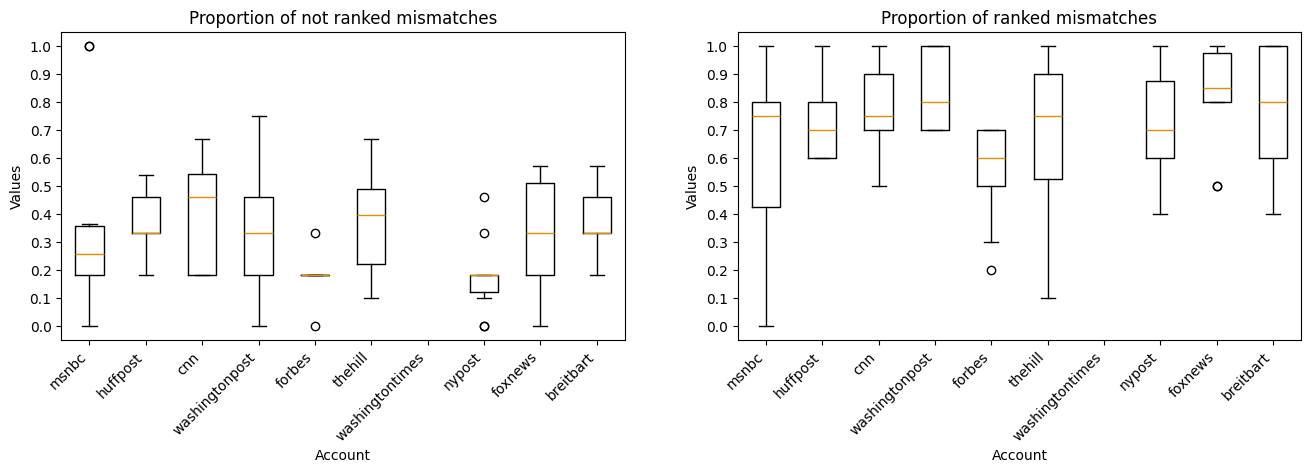

In [15]:
accounts = list(account_fprops_no_rank.keys())
values_no_rank = [account_fprops_no_rank[acc] for acc in accounts]
values_rank = [account_fprops_rank[acc] for acc in accounts]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))

ax1.boxplot(values_no_rank, tick_labels=accounts)
ax1.set_title("Proportion of not ranked mismatches")
ax1.set_xlabel("Account")
ax1.set_ylabel("Values")
ax1.set_xticks(range(1, 11))
ax1.set_xticklabels(accounts, rotation=45, ha='right')
ax1.set_yticks(np.arange(0, 1.1, 0.1))

ax2.boxplot(values_rank, tick_labels=accounts)
ax2.set_title("Proportion of ranked mismatches")
ax2.set_xlabel("Account")
ax2.set_ylabel("Values")
ax2.set_xticks(range(1, 11))
ax2.set_xticklabels(accounts, rotation=45, ha='right')
ax2.set_yticks(np.arange(0, 1.1, 0.1))

plt.show()

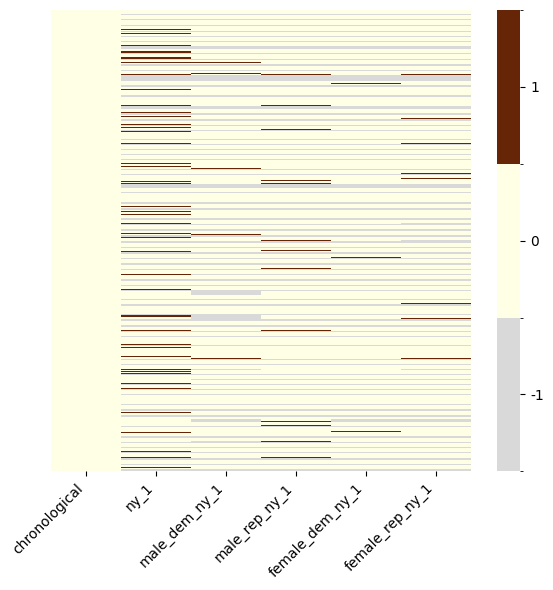

In [16]:
# col1 = 'chronological_comment'
# col2 = 'ny_1_comment'
# col3 = 'texas_1_comment'
# col4 = 'male_dem_ny_1_comment'
# col5 = 'male_dem_texas_1_comment'
# col6 = 'male_rep_ny_1_comment'
# col7 = 'male_rep_texas_1_comment'
# col8 = 'female_dem_ny_1_comment'
# col9 = 'female_dem_texas_1_comment' 
# col10 = 'female_rep_ny_1_comment'
# col11 = 'female_rep_texas_1_comment'

# cols = [col1, col2, col3, col4, col5,
#         col6, col7, col8, col9, col10, col11]

col1 = 'chronological_comment'
col2 = 'ny_1_comment'
col3 = 'male_dem_ny_1_comment'
col4 = 'male_rep_ny_1_comment'
col5 = 'female_dem_ny_1_comment'
col6 = 'female_rep_ny_1_comment'

cols = [col1, col2, col3, col4, col5,
        col6]


codes = []
for idx, x in zip(merged_df.index, zip(*(merged_df[c] for c in cols))):

    temp_code = []
    for i, a in enumerate(x):
        if pd.isna(a):
            code = -1
        else:
            acc_comments = []
            
            if i == 0:
                remove_col = col1
            elif i == 1:
                remove_col = col2
            elif i == 2:
                remove_col = col3
            elif i == 3:
                remove_col = col4
            elif i == 4:
                remove_col = col5
            elif i == 5:
                remove_col = col6
            # elif i == 6:
            #     remove_col = col7
            # elif i == 7:
            #     remove_col = col8
            # elif i == 8:
            #     remove_col = col9
            # elif i == 9:
            #     remove_col = col10
            # elif i == 10:
            #     remove_col = col11

            for c in cols:
                if c == remove_col:
                    continue
                if c == col1:
                    continue
                acc = merged_df.loc[idx, 'account']
                url = merged_df.loc[idx, 'urlid']
                acc_comments += merged_df[(merged_df['account'] == acc) & (merged_df['urlid'] == url)][c].dropna().unique().tolist() 

            if a in set(acc_comments):
                code = 0
            else:
                code = 1

        temp_code.append(code)
    codes.append(temp_code)

codes = np.array(codes)

max_code = codes[codes >= 0].max() if np.any(codes >= 0) else -1
num_groups = max_code + 1

base_cmap = plt.cm.YlOrBr(np.linspace(0, 1, max(num_groups, 1)))
colors = np.vstack(([0.85, 0.85, 0.85, 1.0], base_cmap))
cmap = ListedColormap(colors)

bounds = np.arange(-1.5, num_groups + 0.5, 1)
norm = BoundaryNorm(bounds, cmap.N)

fig, ax = plt.subplots(figsize=(6, 6))

sns.heatmap(
    codes,
    annot=False,
    cmap=cmap,
    norm=norm,
    vmin=-1,
    vmax=max_code,
    cbar=True,                      
    linewidths=0,
    yticklabels=False,
    xticklabels=[c.replace('_comment', '') for c in cols],
    ax=ax
)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
cbar = ax.collections[0].colorbar
cbar.set_ticks([-1, 0, 1])
cbar.set_ticklabels([
    "-1",
    "0",
    "1",
])

# optional: add dotted separators for groups (your urlid trick)
# indices = merged_df["urlid"].drop_duplicates().index
# for y in indices:
#     ax.hlines(y, *ax.get_xlim(), linestyles="dotted", linewidth=1, color="black")

plt.tight_layout()
plt.show()


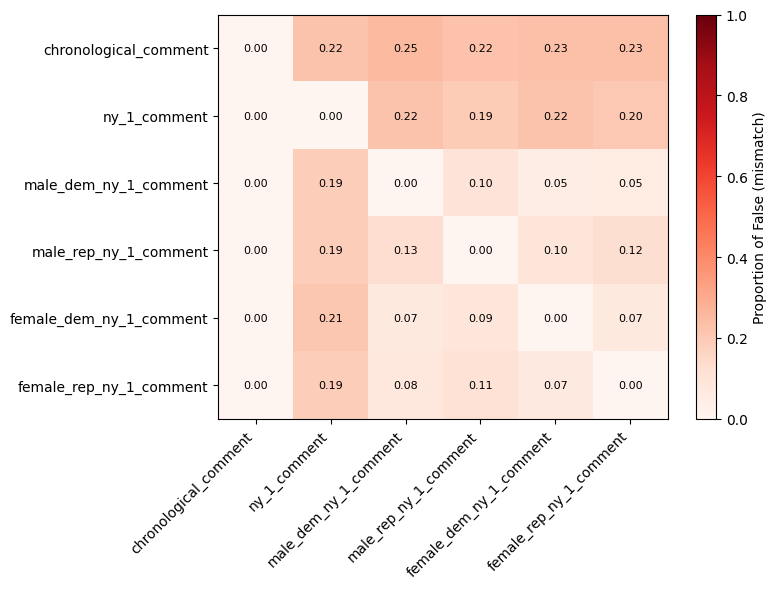

In [17]:
key_cols = ["account", "urlid"]

group_comments = {}
for key, g in merged_df.groupby(key_cols, sort=False):
    group_comments[key] = {
        col: set(g[col].dropna())
        for col in cols
    }

overall_not_covered = pd.DataFrame(index=cols, columns=cols, dtype=float)

for c1 in cols:
    for c2 in cols:
        if c1 == c2:
            overall_not_covered.loc[c1, c2] = 0.0
            continue

        total = 0
        not_covered = 0

        for key, d in group_comments.items():
            s1 = d[c1]
            s2 = d[c2]
            if not s1:
                continue

            total += len(s1)
            not_covered += len(s1 - s2)

        overall_not_covered.loc[c1, c2] = not_covered / total if total else 0.0



fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(
    overall_not_covered.values,
    aspect='auto',
    cmap='Reds',
    vmin=0, vmax=1
)

ax.set_xticks(range(len(cols)))
ax.set_yticks(range(len(cols)))
ax.set_xticklabels(cols, rotation=45, ha='right')
ax.set_yticklabels(cols)

for i in range(len(cols)):
    for j in range(len(cols)):
        ax.text(j, i, f"{overall_not_covered.iloc[i, j]:.2f}",
                ha='center', va='center', fontsize=8)

cbar = fig.colorbar(im, ax=ax, cmap='Blues')
cbar.set_label('Proportion of False (mismatch)')

plt.tight_layout()
plt.show()


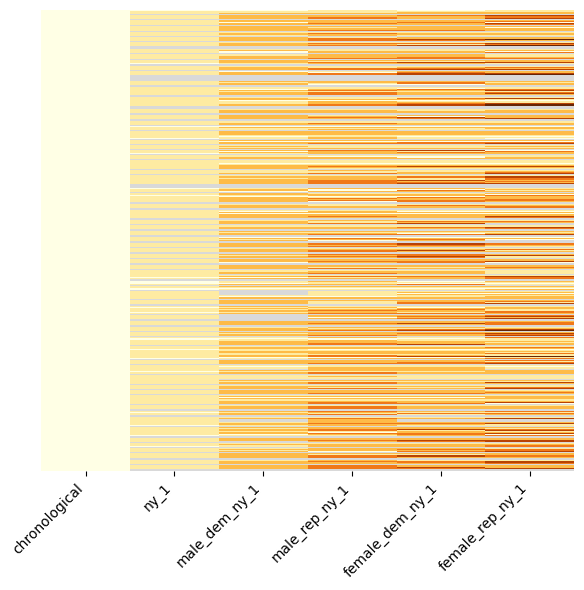

In [18]:
codes = []
for x in zip(*(merged_df[c] for c in cols)):
    present_already = []
    temp_code = []
    for a in x:
        if pd.isna(a):
            c = -1
        else:
            if a not in present_already:
                c = len(present_already)
                present_already.append(a)
            else:
                c = present_already.index(a)
        temp_code.append(c)
    codes.append(temp_code)

codes = np.array(codes)

max_code = codes[codes >= 0].max() if np.any(codes >= 0) else -1
num_groups = max_code + 1

base_cmap = plt.cm.YlOrBr(np.linspace(0, 1, max(num_groups, 1)))
colors = np.vstack(([0.85, 0.85, 0.85, 1.0], base_cmap))
cmap = ListedColormap(colors)

bounds = np.arange(-1.5, num_groups + 0.5, 1)
norm = BoundaryNorm(bounds, cmap.N)

fig, ax = plt.subplots(figsize=(6, 6))

sns.heatmap(
    codes,
    annot=False,
    cmap=cmap,
    norm=norm,
    vmin=-1,
    vmax=max_code,
    cbar=False,                      
    linewidths=0,
    yticklabels=False,
    xticklabels=[c.replace('_comment', '') for c in cols],
    ax=ax
)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

# optional: add dotted separators for groups (your urlid trick)
# indices = merged_df["urlid"].drop_duplicates().index
# for y in indices:
#     ax.hlines(y, *ax.get_xlim(), linestyles="dotted", linewidth=1, color="black")

plt.tight_layout()
plt.show()


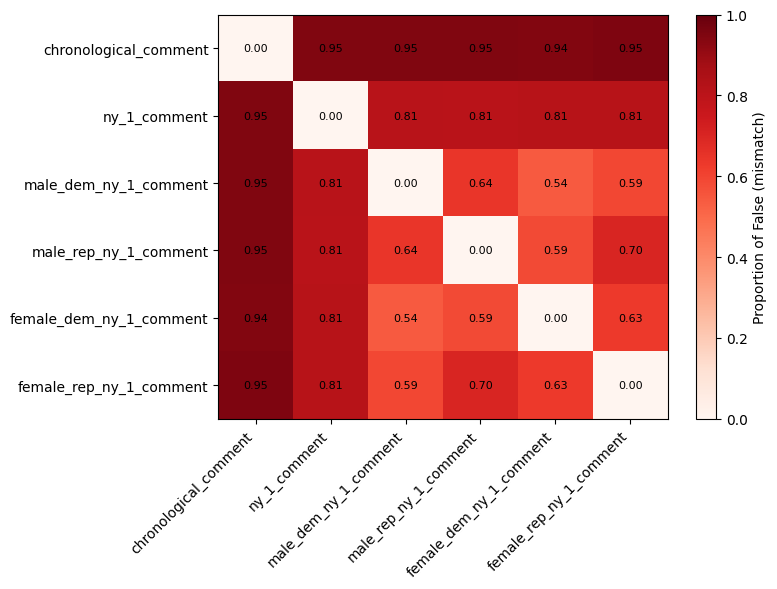

In [19]:
false_ratio = pd.DataFrame(index=cols, columns=cols, dtype=float)

for c1 in cols:
    for c2 in cols:
        if c1 == c2:
            false_ratio.loc[c1, c2] = 0.0
        else:
            comp = merged_df[c1] == merged_df[c2]
            false_ratio.loc[c1, c2] = (~comp).mean()
            false_ratio.loc[c2, c1] = false_ratio.loc[c1, c2]


fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(
    false_ratio.values,
    aspect='auto',
    cmap='Reds',
    vmin=0, vmax=1
)

ax.set_xticks(range(len(cols)))
ax.set_yticks(range(len(cols)))
ax.set_xticklabels(cols, rotation=45, ha='right')
ax.set_yticklabels(cols)

for i in range(len(cols)):
    for j in range(len(cols)):
        ax.text(j, i, f"{false_ratio.iloc[i, j]:.2f}",
                ha='center', va='center', fontsize=8)

cbar = fig.colorbar(im, ax=ax, cmap='Blues')
cbar.set_label('Proportion of False (mismatch)')

plt.tight_layout()
plt.show()


### Regression Analysis

In [14]:
reg_df = pd.DataFrame(columns=['account', 'urlid', 'gender', 'ideology', 'fcount_no_rank', 'ftrials_no_rank', 'fcount_rank', 'ftrials_rank'])

temp_list = []
for crawl1 in ['chronological']:
    for crawl2 in tqdm(all_crawls):

        if crawl1 == crawl2:
            continue

        temp_dict = {}

        _, _, merged_df = compute_fprops(crawl1, crawl2, merged_df, all_urls)
        temp_df = merged_df[['account', 'urlid', 'fcount_no_rank', 'ftrials_no_rank', 'fcount_rank', 'ftrials_rank']].drop_duplicates()

        # location = "none"
        # if 'ny' in crawl2:
        #     location = 'ny'
        # elif 'texas' in crawl2:
        #     location = 'texas'

        gender = "none"
        # gender = None
        if 'female' in crawl2:
            gender = 'female'
        elif 'male' in crawl2:
            gender = 'male'

        ideology = "none"
        # ideology = None
        if 'dem' in crawl2:
            ideology = 'dem'
        elif 'rep' in crawl2:
            ideology = 'rep'

        # gender_ideology = gender + '_' + ideology + '_' + location
        gender_ideology = gender + '_' + ideology 

        # temp_dict['location'] = location
        temp_dict['gender'] = gender
        temp_dict['ideology'] = ideology
        temp_dict['gender_ideology'] = gender_ideology

        for index, row in temp_df.iterrows():
            temp_dict['urlid'] = row['urlid']
            temp_dict['account'] = row['account']
            temp_dict['fcount_no_rank'] = row['fcount_no_rank']
            temp_dict['ftrials_no_rank'] = row['ftrials_no_rank']
            temp_dict['fcount_rank'] = row['fcount_rank'] 
            temp_dict['ftrials_rank'] = row['ftrials_rank']
            temp_list.append(temp_dict.copy())


reg_df = pd.DataFrame(temp_list)        
reg_df.shape

 20%|██        | 1/5 [00:00<00:02,  1.74it/s]

(1102, 11)


KeyError: "['ftrials_no_rank', 'ftrials_rank'] not in index"

In [14]:
reg_df.duplicated().sum()

np.int64(0)

In [15]:
reg_df['account'].value_counts()

account
cnn               40
foxnews           40
msnbc             40
nypost            40
thehill           40
breitbart         36
forbes            36
huffpost          36
washingtonpost    36
Name: count, dtype: int64

In [16]:
accounts_data = pd.read_excel('/Users/brahmaninutakki/saarland/insta-comments/News Sites US.xlsx', sheet_name='Sheet3')
accounts_data.head(3)

,account,political_ideology,reporting_quality,credibility,posts,followers,following
0,msnbc,Left,Mixed,Medium,16790,2400000,308
1,huffpost,Left,Mixed,Medium,12119,3300000,708
2,cnn,Center-Left,Mostly Factual,Medium,21936,21700000,289


In [17]:
reg_df = pd.merge(reg_df, accounts_data, on='account', how='inner')
reg_df.shape

(344, 15)

In [18]:
posts_data = pd.read_excel('/Users/brahmaninutakki/saarland/insta-comments/[updated]News Sites US.xlsx', sheet_name='New data topics')
posts_data['urlid'] = posts_data['Url'].apply(lambda x: x.split('/')[-2] if x.endswith('/') else x.split('/')[-1])
posts_data = posts_data[posts_data['urlid'].isin(reg_df['urlid'].unique().tolist())]
posts_data.shape[0] == reg_df['urlid'].nunique()

True

In [19]:
reg_df = pd.merge(reg_df, posts_data, on='urlid', how='inner')
reg_df.shape

(344, 17)

In [20]:
reg_df['Main Topic'].value_counts()

Main Topic
Political        188
Non-Political    156
Name: count, dtype: int64

In [21]:
reg_df['gender_ideology'].value_counts()

gender_ideology
male_dem      86
male_rep      86
female_dem    86
female_rep    86
Name: count, dtype: int64

In [22]:
reg_df['fcount_no_rank'] = reg_df['fcount_no_rank'].astype(int)
reg_df['ftrials_no_rank'] = reg_df['ftrials_no_rank'].astype(int)
reg_df['fcount_rank'] = reg_df['fcount_rank'].astype(int)
reg_df['ftrials_rank'] = reg_df['ftrials_rank'].astype(int)

(reg_df[reg_df['fcount_no_rank'] > reg_df['ftrials_no_rank']]).shape, (reg_df[reg_df['fcount_rank'] > reg_df['ftrials_rank']]).shape

((0, 17), (0, 17))

In [23]:
reg_df['political_ideology'] = reg_df['political_ideology'].replace({'Right': 'Right',
                                      'Center-Left': 'Left',
                                      'Center': 'Center',
                                      'Left': 'Left',
                                      'Center-Right': 'Right'})

reg_df['political_ideology'].value_counts()

political_ideology
Left      152
Right     116
Center     76
Name: count, dtype: int64

In [24]:
reg_df['gender_ideology'].value_counts()

gender_ideology
male_dem      86
male_rep      86
female_dem    86
female_rep    86
Name: count, dtype: int64

In [25]:
# reg_df["gender_ideology"] = pd.Categorical(
#     reg_df["gender_ideology"],
#     categories=["none_none_ny", "none_none_texas", "male_dem_ny", "male_dem_texas", "male_rep_ny", "male_rep_texas",
#                 "female_dem_ny", "female_dem_texas", "female_rep_ny", "female_rep_texas"],
#     ordered=True
# )

reg_df["gender_ideology"] = pd.Categorical(
    reg_df["gender_ideology"],
    categories=["male_dem", "male_rep", "female_dem", "female_rep"],
    # categories=["none_none", "male_dem", "male_rep", "female_dem", "female_rep"],
    ordered=True
)

for col in ["posts", "followers", "following"]:
    # reg_df[col + "_z"] = (reg_df[col] - reg_df[col].mean()) / reg_df[col].std()
    reg_df[col + "_log"] = np.log1p(reg_df[col])


reg_df["ideology"] = pd.Categorical(
    reg_df["ideology"],
    categories=["none", "dem", "rep"],
    ordered=True
)
reg_df["gender"] = pd.Categorical(
    reg_df["gender"],
    categories=["none", "female", "male"],
    ordered=True
)
# reg_df["location"] = pd.Categorical(
#     reg_df["location"],
#     categories=["ny", "texas"],
#     ordered=True
# )

reg_df['Main Topic'] = pd.Categorical(reg_df['Main Topic'], categories=['Non-Political', 'Political'], ordered=True)
reg_df.rename(columns={'Main Topic': 'main_topic'}, inplace=True)

In [26]:
reg_df[["posts", "followers", "following"]].corr()

,posts,followers,following
posts,1.000000,0.160526,-0.207310
followers,0.160526,1.000000,-0.119728
following,-0.207310,-0.119728,1.000000


In [27]:
reg_df['gender_ideology'].value_counts()
# reg_df[['gender', 'ideology', 'location']].value_counts()

gender_ideology
male_dem      86
male_rep      86
female_dem    86
female_rep    86
Name: count, dtype: int64

In [28]:
reg_df.head()

,gender,ideology,gender_ideology,urlid,account,fcount_no_rank,ftrials_no_rank,fcount_rank,ftrials_rank,political_ideology,reporting_quality,credibility,posts,followers,following,Url,main_topic,posts_log,followers_log,following_log
0,male,dem,male_dem,DRWBiQXDG0H,breitbart,2,11,4,10,Right,Mixed,Low,34864,1800000,362,https://www.instagram.com/wearebreitbart/reel/...,Political,10.459239,14.403298,5.894403
1,male,dem,male_dem,DRWXFT9DRtK,breitbart,8,14,10,10,Right,Mixed,Low,34864,1800000,362,https://www.instagram.com/wearebreitbart/p/DRW...,Political,10.459239,14.403298,5.894403
2,male,dem,male_dem,DRWhnmjDo-i,breitbart,6,13,10,10,Right,Mixed,Low,34864,1800000,362,https://www.instagram.com/wearebreitbart/p/DRW...,Political,10.459239,14.403298,5.894403
3,male,dem,male_dem,DRXIibxjFKK,breitbart,4,12,10,10,Right,Mixed,Low,34864,1800000,362,https://www.instagram.com/wearebreitbart/reel/...,Political,10.459239,14.403298,5.894403
4,male,dem,male_dem,DRXUNHfDYvW,breitbart,6,13,7,10,Right,Mixed,Low,34864,1800000,362,https://www.instagram.com/wearebreitbart/p/DRX...,Non-Political,10.459239,14.403298,5.894403


In [29]:
reg_df['gender_ideology'].value_counts()

gender_ideology
male_dem      86
male_rep      86
female_dem    86
female_rep    86
Name: count, dtype: int64

In [33]:
# formula = "fcount_no_rank ~ C(gender_ideology) + C(political_ideology) + C(reporting_quality) + C(credibility) + C(main_topic) + posts_log + followers_log + following_log" 
formula = "fcount_no_rank ~ C(gender_ideology) + C(political_ideology) + C(main_topic) + followers_log + following_log" 
get_vif(formula, reg_df)

,feature,VIF
6,C(main_topic)[T.Political],1.442237
1,C(gender_ideology)[T.male_rep],1.500000
2,C(gender_ideology)[T.female_dem],1.500000
3,C(gender_ideology)[T.female_rep],1.500000
7,followers_log,1.722801
8,following_log,1.984612
5,C(political_ideology)[T.Right],2.689496
4,C(political_ideology)[T.Left],4.299164
0,Intercept,369.148205


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, gender_ideology, political_ideology, main_topic, followers_log, following_log, 1|account_sigma, 1|account_offset]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 30 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,-1.301,2.769,-6.692,3.816,0.041,0.061,4833.0,4269.0,1.0
gender_ideology[male_rep],-0.089,0.096,-0.279,0.080,0.001,0.001,8243.0,6635.0,1.0
gender_ideology[female_dem],0.070,0.095,-0.103,0.247,0.001,0.001,7150.0,6197.0,1.0
gender_ideology[female_rep],-0.047,0.094,-0.223,0.130,0.001,0.001,7332.0,6407.0,1.0
political_ideology[Left],0.352,0.512,-0.626,1.298,0.008,0.007,4301.0,4605.0,1.0
political_ideology[Right],0.222,0.471,-0.676,1.095,0.008,0.009,4087.0,4082.0,1.0
main_topic[Political],0.387,0.096,0.202,0.563,0.001,0.001,10896.0,5973.0,1.0
followers_log,0.073,0.169,-0.248,0.396,0.003,0.004,4339.0,3827.0,1.0
following_log,-0.173,0.308,-0.742,0.421,0.005,0.005,4669.0,4987.0,1.0
1|account_sigma,0.493,0.248,0.164,0.908,0.006,0.010,2162.0,3140.0,1.0


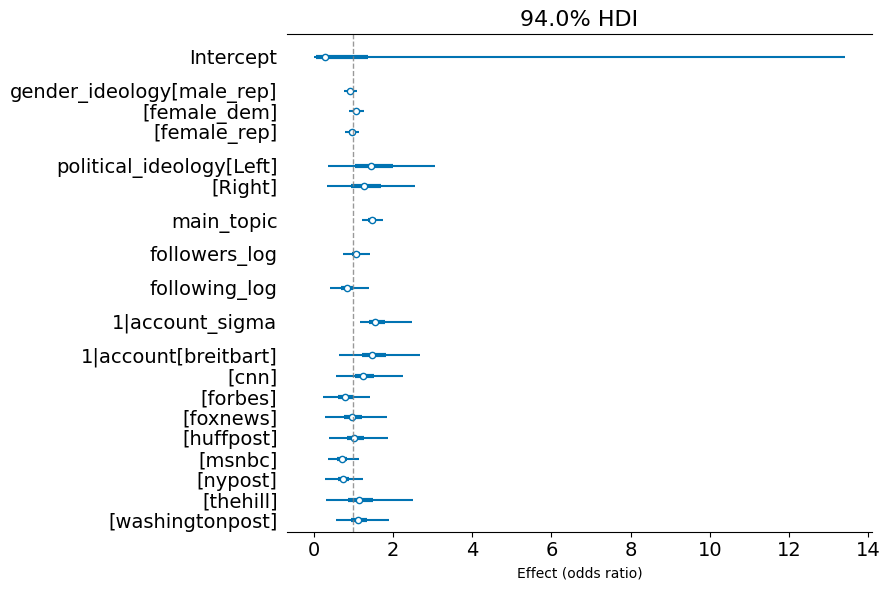

In [34]:
model = bmb.Model(
    "p(fcount_no_rank, ftrials_no_rank) ~ gender_ideology + political_ideology + main_topic + followers_log + following_log + (1|account)",
    data=reg_df,
    family="binomial",
    dropna=True
)

results = model.fit(
    draws=2000,      
    tune=2000,       
    target_accept=0.99,
    chains=4
)
display(az.summary(results))

axes = az.plot_forest(
    results,
    combined=True,
    hdi_prob=0.94,
    transform=np.exp,
    figsize=(9, 6),
    r_hat=False,
    ess=False,
)

ax = axes[0] if isinstance(axes, (list, np.ndarray)) else axes

ax.axvline(1, linestyle="--", linewidth=1, color="grey", alpha=0.8)
ax.set_xlabel("Effect (odds ratio)")

plt.tight_layout()
plt.show()

In [26]:
merged_df['fcount_no_rank'].value_counts(), merged_df['fcount_rank'].value_counts()

(fcount_no_rank
 1.0    641
 0.0    180
 Name: count, dtype: int64,
 fcount_rank
 0.0    748
 1.0     73
 Name: count, dtype: int64)

In [27]:
merged_df['fcount_no_rank'].isna().sum(), merged_df['fcount_rank'].isna().sum()

(np.int64(281), np.int64(281))

In [29]:
merged_df[merged_df['fcount_no_rank'].isna()]

,account,urlid,comment_num,ny_1_comment,male_dem_ny_1_comment,male_rep_ny_1_comment,female_dem_ny_1_comment,female_rep_ny_1_comment,chronological_comment,fcount_no_rank,fcount_rank
10,breitbart,DRWBiQXDG0H,10,NaN,NaN,NaN,NaN,NaN,"(scottishlyme, The actual LEFT should be calle...",NaN,NaN
21,breitbart,DRWXFT9DRtK,10,NaN,NaN,NaN,NaN,NaN,"(ally_son_mills, I don’t blame her but I’m sad...",NaN,NaN
22,breitbart,DRWXFT9DRtK,11,NaN,NaN,NaN,NaN,NaN,"(matt.mccaffrey, MTG is a Champion for America...",NaN,NaN
23,breitbart,DRWXFT9DRtK,12,NaN,NaN,NaN,NaN,NaN,"(thepalehorse9, She's not wrong. AIPAC runs ou...",NaN,NaN
24,breitbart,DRWXFT9DRtK,13,NaN,NaN,NaN,NaN,NaN,"(jordanbeasley626, Dont blame her. Shes seen t...",NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
1097,washingtonpost,DRYMvrrFks8,11,NaN,NaN,NaN,NaN,NaN,"(tylerlizenby, It costs less than 10% of their...",NaN,NaN
1098,washingtonpost,DRYMvrrFks8,12,NaN,NaN,NaN,NaN,NaN,"(tessakaneene, We know, babe. We've known.)",NaN,NaN
1099,washingtonpost,DRYMvrrFks8,13,NaN,NaN,NaN,NaN,NaN,"(gwyneddstuart, The call is coming from inside...",NaN,NaN
1100,washingtonpost,DRYMvrrFks8,14,NaN,NaN,NaN,NaN,NaN,"(harrison.c.shannon, Okay and the sky is blue.)",NaN,NaN
